# Механизмы адаптации ЛЖ, архитектура хорд и цена адаптации

## Цель ноутбука

В этом ноутбуке мы объединяем две линии анализа:

1. **Механико-гемодинамические фенотипы адаптации ЛЖ к нагрузке**
   - Low / низконагрузочный менее сферичный фенотип;
   - Sphericity / геометрически-сферичный фенотип;
   - Stress / стресс-доминантный фенотип.

2. **Ранее сформированные механистические классификации хорд**
   - `mechanical_chord_phenotype`;
   - `chord_type_complexity_class`;
   - `chord_type_diversity`;
   - `transverse_load`;
   - `oblique_load`;
   - `long_oblique_bridge_load`.

Главный вопрос:

> Связана ли архитектура ложных хорд не напрямую с глобальной функцией ЛЖ, а с типом адаптации ЛЖ и ценой этой адаптации?

## Важное методологическое уточнение

Класс `0_no_selected_types` не означает, что у пациента нет хорд. В нашей выборке у всех пациентов есть ложные хорды. Этот класс означает только то, что пациент не был классифицирован по выбранным архитектурным признакам хорд.

Поэтому его нужно трактовать как:

> не классифицированы по выбранной механистической схеме

а не как:

> пациенты без хорд

## Рабочая логика

Сначала восстанавливаем фенотипы адаптации ЛЖ.  
Потом подтягиваем ранее созданные классы хорд.  
Затем смотрим:

1. отличаются ли фенотипы адаптации по архитектуре хорд;
2. отличаются ли фенотипы адаптации по цене адаптации;
3. какие классификации хорд действительно дают содержательный сигнал.

In [1]:
# ============================================================
# 0. Импорты, пути и стиль графиков
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# Пути
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords"
)

FINAL_DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"
MECH_DATA_PATH = PROJECT_ROOT / "data" / "interim" / "regression_mechanistic_dataset.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "16_adaptation_phenotypes_vs_chord_architecture"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("FINAL_DATA_PATH:", FINAL_DATA_PATH)
print("MECH_DATA_PATH:", MECH_DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

# ------------------------------------------------------------
# Академический стиль графиков
# ------------------------------------------------------------

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.0

plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"

plt.rcParams["grid.color"] = "#D9D9D9"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8


def apply_publication_style(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", colors="black", labelsize=10)

    if grid_axis is not None:
        ax.grid(True, axis=grid_axis, alpha=0.5)

    return ax


def save_fig(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Рисунок сохранён:", path)

FINAL_DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
MECH_DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\interim\regression_mechanistic_dataset.xlsx
OUTPUT_DIR: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture


In [2]:
# ============================================================
# 1. Загрузка финального и механистического датасетов
# ============================================================

df_final = pd.read_excel(FINAL_DATA_PATH)
df_mech = pd.read_excel(MECH_DATA_PATH)

print("Размер df_final:", df_final.shape)
print("Размер df_mech:", df_mech.shape)

print("\nПервые колонки df_final:")
print(df_final.columns[:20].tolist())

print("\nПервые колонки df_mech:")
print(df_mech.columns[:20].tolist())

Размер df_final: (153, 222)
Размер df_mech: (153, 224)

Первые колонки df_final:
['subject_full_name', 'age', 'height_cm', 'weight_cm', 'BSA', 'sex', 'IMT', 'echo_ascending_aorta_diameter_mm_div_bsa', 'echo_ascending_aorta_diameter_mm', 'echo_aortic_sinus_diameter_mm_div_bsa', 'echo_aortic_sinus_diameter_mm', 'echo_aortic_valve_annulus_diameter_mm', 'echo_aortic_cusp_separation_mm', 'Е/А', 'echo_lv_end_diastolic_volume_index_ml_m2', 'echo_lv_end_diastolic_volume_teichholz_ml', 'echo_lv_end_systolic_volume_index_ml_m2', 'echo_lv_end_systolic_volume_teichholz_ml', 'echo_lv_ejection_fraction_teichholz_pct', 'echo_lv_stroke_volume_teichholz_ml']

Первые колонки df_mech:
['subject_full_name', 'age', 'height_cm', 'weight_cm', 'BSA', 'sex', 'IMT', 'echo_ascending_aorta_diameter_mm_div_bsa', 'echo_ascending_aorta_diameter_mm', 'echo_aortic_sinus_diameter_mm_div_bsa', 'echo_aortic_sinus_diameter_mm', 'echo_aortic_valve_annulus_diameter_mm', 'echo_aortic_cusp_separation_mm', 'Е/А', 'echo_lv_end_

In [3]:
# ============================================================
# 2. Перенос ранее созданных механистических признаков хорд
# ============================================================

mechanistic_chord_cols = [
    "transverse_any",
    "transverse_load",
    "oblique_any",
    "oblique_load",
    "long_oblique_bridge_any",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "chord_type_complexity_class",
    "mechanical_chord_phenotype",
]

existing_mechanistic_chord_cols = [
    col for col in mechanistic_chord_cols
    if col in df_mech.columns
]

missing_mechanistic_chord_cols = [
    col for col in mechanistic_chord_cols
    if col not in df_mech.columns
]

print("Найдены механистические признаки хорд:")
for col in existing_mechanistic_chord_cols:
    print("-", col)

if missing_mechanistic_chord_cols:
    print("\nНе найдены:")
    for col in missing_mechanistic_chord_cols:
        print("-", col)

# ------------------------------------------------------------
# Перенос признаков
# ------------------------------------------------------------

df = df_final.copy()

if len(df_final) == len(df_mech):
    print("\nРазмеры совпадают. Переносим признаки по порядку строк.")

    for col in existing_mechanistic_chord_cols:
        df[col] = df_mech[col].values

else:
    raise ValueError(
        "Размеры df_final и df_mech не совпадают. "
        "Нельзя безопасно переносить признаки по порядку строк."
    )

print("\nПроверка распределений:")

for col in [
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
]:
    if col in df.columns:
        print("\n", col)
        display(df[col].value_counts(dropna=False))

Найдены механистические признаки хорд:
- transverse_any
- transverse_load
- oblique_any
- oblique_load
- long_oblique_bridge_any
- long_oblique_bridge_load
- chord_type_diversity
- chord_type_complexity_class
- mechanical_chord_phenotype

Размеры совпадают. Переносим признаки по порядку строк.

Проверка распределений:

 mechanical_chord_phenotype


mechanical_chord_phenotype
Transverse-Involved        66
No-selected-chord-types    55
Oblique-Only               32
Name: count, dtype: int64


 chord_type_complexity_class


chord_type_complexity_class
0_no_selected_types    55
3_complex_network      50
2_two_types            28
1_single_type          20
Name: count, dtype: int64

In [4]:
# ============================================================
# 3. Группы переменных для анализа
# ============================================================

# Механизм адаптации ЛЖ к нагрузке
adaptation_vars = [
    "dsws",
    "echo_lv_sws_delta_g_cm2",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
]

# Архитектура хорд
chord_architecture_vars = [
    "lv_false_tendon_total_count",
    "transverse_any",
    "transverse_load",
    "oblique_any",
    "oblique_load",
    "long_oblique_bridge_any",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "chord_type_complexity_class",
    "mechanical_chord_phenotype",
]

# Цена адаптации
adaptation_cost_vars = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
    "merged_lv_deformation_cv_pct",
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
]

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",

    "lv_false_tendon_total_count": "Количество ложных хорд",
    "transverse_any": "Есть поперечный компонент",
    "transverse_load": "Поперечный компонент",
    "oblique_any": "Есть косой компонент",
    "oblique_load": "Косой компонент",
    "long_oblique_bridge_any": "Есть длинный косой мост",
    "long_oblique_bridge_load": "Длинные косые мосты",
    "chord_type_diversity": "Разнообразие типов хорд",
    "chord_type_complexity_class": "Сложность сети хорд",
    "mechanical_chord_phenotype": "Механический фенотип хорд",

    "dicor_ssou_cv_pct": "DICOR CV ССОУ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR CV КДТР, %",
    "merged_lv_deformation_cv_pct": "Интегральный CV деформации ЛЖ, %",
    "echo_lv_strain_plus_cv_pct": "CV strain, %",
    "echo_lv_strain_rate_cv_pct": "CV strain rate, %",
}

all_key_vars = adaptation_vars + chord_architecture_vars + adaptation_cost_vars

audit = []

for col in all_key_vars:
    audit.append({
        "variable": col,
        "exists": col in df.columns,
        "n_non_missing": df[col].notna().sum() if col in df.columns else np.nan,
        "n_unique": df[col].nunique(dropna=True) if col in df.columns else np.nan,
        "dtype": str(df[col].dtype) if col in df.columns else None,
    })

audit_df = pd.DataFrame(audit)

display(audit_df)

audit_df.to_excel(TABLES_DIR / "00_key_variables_audit.xlsx", index=False)

,variable,exists,n_non_missing,n_unique,dtype
0,dsws,True,66,30,float64
1,echo_lv_sws_delta_g_cm2,True,33,33,float64
2,echo_lv_sphericity_index_end_systolic_ratio,True,100,74,float64
3,echo_lv_sphericity_index_end_diastolic_ratio,True,100,72,float64
4,lv_false_tendon_total_count,True,132,7,float64
5,transverse_any,True,153,2,int64
6,transverse_load,True,87,6,float64
7,oblique_any,True,153,2,int64
8,oblique_load,True,90,5,float64
9,long_oblique_bridge_any,True,153,2,int64


In [5]:
# ============================================================
# 4. Реконструкция механико-гемодинамических фенотипов адаптации
# ============================================================

adaptation_df = df[adaptation_vars].copy()

complete_mask = adaptation_df.notna().all(axis=1)
adaptation_complete = adaptation_df.loc[complete_mask].copy()

print("Полные случаи по переменным адаптации:", adaptation_complete.shape[0])

# ------------------------------------------------------------
# Исключаем экстремальный ΔSWS через IQR
# ------------------------------------------------------------

sws_col = "echo_lv_sws_delta_g_cm2"

q1 = adaptation_complete[sws_col].quantile(0.25)
q3 = adaptation_complete[sws_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (
    (adaptation_complete[sws_col] < lower_bound) |
    (adaptation_complete[sws_col] > upper_bound)
)

adaptation_outliers = adaptation_complete.loc[outlier_mask].copy()
adaptation_no_outlier = adaptation_complete.loc[~outlier_mask].copy()

print("Граница выбросов ΔSWS:")
print("lower:", round(lower_bound, 2))
print("upper:", round(upper_bound, 2))

print("\nЭкстремальные наблюдения по ΔSWS:", adaptation_outliers.shape[0])
display(adaptation_outliers)

print("\nВыборка для кластеризации:", adaptation_no_outlier.shape[0])

# ------------------------------------------------------------
# Стандартизация и KMeans k=3
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(adaptation_no_outlier[adaptation_vars]),
    columns=adaptation_vars,
    index=adaptation_no_outlier.index,
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50,
)

cluster_labels = kmeans.fit_predict(X_scaled)

adaptation_clusters = adaptation_no_outlier.copy()
adaptation_clusters["adaptation_cluster_k3"] = cluster_labels

X_scaled_with_clusters = X_scaled.copy()
X_scaled_with_clusters["adaptation_cluster_k3"] = cluster_labels

z_profile = (
    X_scaled_with_clusters
    .groupby("adaptation_cluster_k3")[adaptation_vars]
    .mean()
)

print("\nРазмеры кластеров:")
display(adaptation_clusters["adaptation_cluster_k3"].value_counts().sort_index())

print("\nZ-профиль кластеров:")
display(z_profile.round(2))

print("\nSilhouette k=3:", round(silhouette_score(X_scaled, cluster_labels), 3))

Полные случаи по переменным адаптации: 27
Граница выбросов ΔSWS:
lower: -16.26
upper: 63.06

Экстремальные наблюдения по ΔSWS: 1


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
55,21.0,135.312821,0.472,0.469



Выборка для кластеризации: 26

Размеры кластеров:


adaptation_cluster_k3
0     9
1    10
2     7
Name: count, dtype: int64


Z-профиль кластеров:


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
adaptation_cluster_k3,,,,
0,0.27,0.08,0.93,1.04
1,-0.66,-0.80,-0.71,-0.34
2,0.59,1.05,-0.18,-0.85



Silhouette k=3: 0.266


In [6]:
# ============================================================
# 5. Автоматическое название фенотипов по z-профилю
# ============================================================

z = z_profile.copy()

# Stress = максимальный ΔSWS
stress_cluster = z["echo_lv_sws_delta_g_cm2"].idxmax()

# Sphericity = максимальная средняя сферичность КС+КД среди оставшихся
z["mean_sphericity"] = z[
    [
        "echo_lv_sphericity_index_end_systolic_ratio",
        "echo_lv_sphericity_index_end_diastolic_ratio",
    ]
].mean(axis=1)

remaining_clusters = [c for c in z.index if c != stress_cluster]
sphericity_cluster = z.loc[remaining_clusters, "mean_sphericity"].idxmax()

# Low = оставшийся
low_cluster = [c for c in z.index if c not in [stress_cluster, sphericity_cluster]][0]

cluster_to_phenotype = {
    low_cluster: "Low",
    sphericity_cluster: "Sphericity",
    stress_cluster: "Stress",
}

cluster_to_phenotype_ru = {
    low_cluster: "Низконагрузочный менее сферичный фенотип",
    sphericity_cluster: "Геометрически-сферичный фенотип",
    stress_cluster: "Стресс-доминантный фенотип",
}

print("Маппинг кластеров:")
for cluster_id in sorted(cluster_to_phenotype):
    print(cluster_id, "→", cluster_to_phenotype[cluster_id])

adaptation_clusters["adaptation_phenotype"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_to_phenotype)
)

adaptation_clusters["adaptation_phenotype_ru"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_to_phenotype_ru)
)

# Экстремальный ΔSWS сохраняем отдельно
adaptation_outliers_labeled = adaptation_outliers.copy()
adaptation_outliers_labeled["adaptation_cluster_k3"] = pd.NA
adaptation_outliers_labeled["adaptation_phenotype"] = "Extreme"
adaptation_outliers_labeled["adaptation_phenotype_ru"] = "Экстремальный ΔSWS"

adaptation_phenotypes = pd.concat(
    [
        adaptation_clusters,
        adaptation_outliers_labeled,
    ],
    axis=0
).sort_index()

print("\nРаспределение фенотипов:")
display(adaptation_phenotypes["adaptation_phenotype"].value_counts(dropna=False))

Маппинг кластеров:
0 → Sphericity
1 → Low
2 → Stress

Распределение фенотипов:


adaptation_phenotype
Low           10
Sphericity     9
Stress         7
Extreme        1
Name: count, dtype: int64

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
adaptation_phenotype,,,,
Low,-0.66,-0.80,-0.71,-0.34
Sphericity,0.27,0.08,0.93,1.04
Stress,0.59,1.05,-0.18,-0.85


Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\01_z_profile_adaptation_phenotypes.png


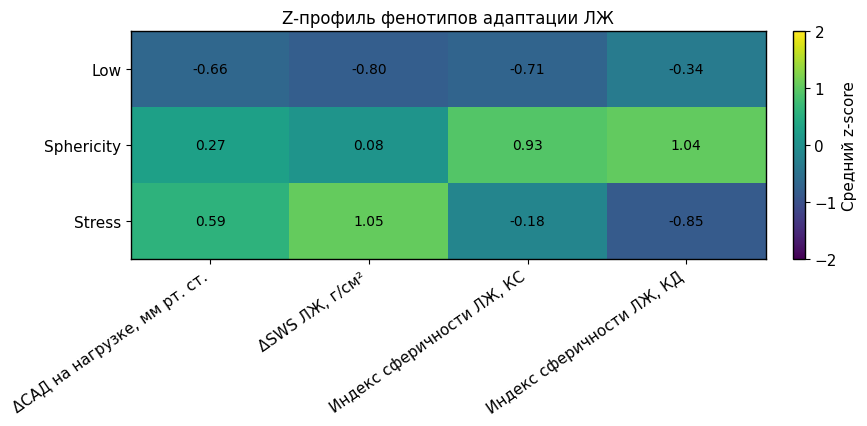

In [7]:
# ============================================================
# 6. Heatmap профиля фенотипов адаптации
# ============================================================

phenotype_order = ["Low", "Sphericity", "Stress"]
phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
]

X_plot = X_scaled.copy()
X_plot["adaptation_phenotype"] = adaptation_clusters["adaptation_phenotype"]

z_profile_named = (
    X_plot
    .groupby("adaptation_phenotype")[adaptation_vars]
    .mean()
    .reindex(phenotype_order)
)

display(z_profile_named.round(2))

fig, ax = plt.subplots(figsize=(9, 4.4))

profile = z_profile_named.copy()
profile.columns = [pretty_names.get(c, c) for c in profile.columns]

im = ax.imshow(profile.values, aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(profile.shape[1]))
ax.set_yticks(range(profile.shape[0]))

ax.set_xticklabels(profile.columns, rotation=35, ha="right")
ax.set_yticklabels(phenotype_order)

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(
            j,
            i,
            f"{profile.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10,
        )

ax.set_title("Z-профиль фенотипов адаптации ЛЖ")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Средний z-score")

plt.tight_layout()

save_fig(fig, "01_z_profile_adaptation_phenotypes.png")
plt.show()

In [8]:
# ============================================================
# 7. Сборка итоговой таблицы analysis_df
# ============================================================

analysis_df = df.copy()

analysis_df = analysis_df.join(
    adaptation_phenotypes[
        [
            "adaptation_cluster_k3",
            "adaptation_phenotype",
            "adaptation_phenotype_ru",
        ]
    ],
    how="left",
)

main_df = analysis_df[
    analysis_df["adaptation_phenotype"].isin(phenotype_order)
].copy()

print("Размер analysis_df:", analysis_df.shape)
print("Размер main_df:", main_df.shape)

print("\nРаспределение фенотипов адаптации:")
display(main_df["adaptation_phenotype"].value_counts().reindex(phenotype_order))

print("\nРаспределение mechanical_chord_phenotype:")
if "mechanical_chord_phenotype" in main_df.columns:
    display(main_df["mechanical_chord_phenotype"].value_counts(dropna=False))

print("\nРаспределение chord_type_complexity_class:")
if "chord_type_complexity_class" in main_df.columns:
    display(main_df["chord_type_complexity_class"].value_counts(dropna=False))

analysis_df.to_excel(
    TABLES_DIR / "01_analysis_dataset_with_adaptation_and_chord_classes.xlsx",
    index=True,
)

print("Таблица сохранена:", TABLES_DIR / "01_analysis_dataset_with_adaptation_and_chord_classes.xlsx")

Размер analysis_df: (153, 234)
Размер main_df: (26, 234)

Распределение фенотипов адаптации:


adaptation_phenotype
Low           10
Sphericity     9
Stress         7
Name: count, dtype: int64


Распределение mechanical_chord_phenotype:


mechanical_chord_phenotype
Transverse-Involved        15
Oblique-Only                9
No-selected-chord-types     2
Name: count, dtype: int64


Распределение chord_type_complexity_class:


chord_type_complexity_class
3_complex_network      15
2_two_types             5
1_single_type           4
0_no_selected_types     2
Name: count, dtype: int64

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\tables\01_analysis_dataset_with_adaptation_and_chord_classes.xlsx


Доступные переменные цены адаптации:
- dicor_ssou_cv_pct n = 24
- dicor_sm_kdtr_cv_pct n = 24
- merged_lv_deformation_cv_pct n = 24
Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\02_adaptation_cost_by_phenotype.png


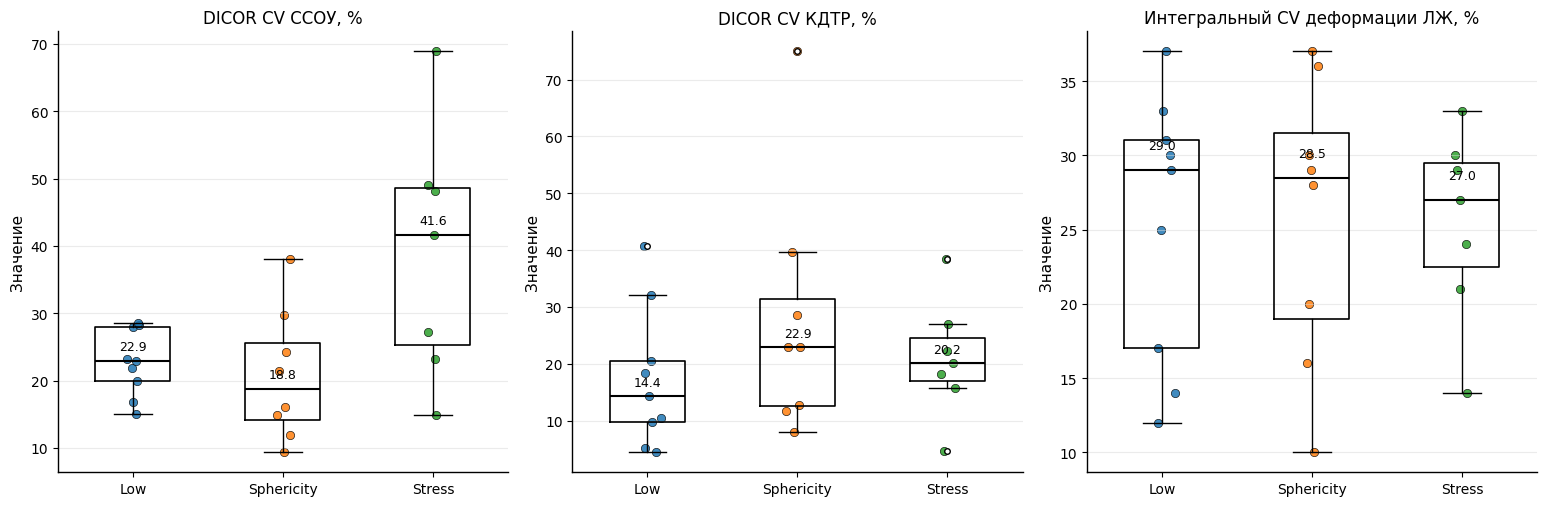

In [9]:
# ============================================================
# 8. Цена адаптации по фенотипам ЛЖ
# ============================================================

available_cost_vars = [
    col for col in [
        "dicor_ssou_cv_pct",
        "dicor_sm_kdtr_cv_pct",
        "merged_lv_deformation_cv_pct",
    ]
    if col in main_df.columns and main_df[col].notna().sum() > 0
]

print("Доступные переменные цены адаптации:")
for col in available_cost_vars:
    print("-", col, "n =", main_df[col].notna().sum())

fig, axes = plt.subplots(1, len(available_cost_vars), figsize=(5.2 * len(available_cost_vars), 5.2))

if len(available_cost_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, available_cost_vars):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype"] == phenotype,
            col,
        ].dropna()
        for phenotype in phenotype_order
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.04, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=36,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.85,
        )

    medians = [np.median(values) for values in data_by_group]
    for i, med in enumerate(medians, start=1):
        ax.text(
            i,
            med + 1.2,
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(phenotype_order)

    apply_publication_style(ax)

plt.tight_layout()

save_fig(fig, "02_adaptation_cost_by_phenotype.png")
plt.show()

In [10]:
# ============================================================
# 9. Подготовка хордовых классификаций
# ============================================================

categorical_chord_vars = [
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
]

categorical_chord_vars = [
    col for col in categorical_chord_vars
    if col in main_df.columns
]

category_orders = {
    "mechanical_chord_phenotype": [
        "No-selected-chord-types",
        "Oblique-Only",
        "Transverse-Involved",
    ],
    "chord_type_complexity_class": [
        "0_no_selected_types",
        "1_single_type",
        "2_two_types",
        "3_complex_network",
    ],
}

print("Категориальные хордовые переменные:")
for col in categorical_chord_vars:
    print("-", col)

print("\nРаспределение по всей main_df:")

for col in categorical_chord_vars:
    print("\n" + "=" * 80)
    print(col)

    order = [
        x for x in category_orders.get(col, sorted(main_df[col].dropna().unique()))
        if x in main_df[col].dropna().unique()
    ]

    display(
        main_df[col]
        .value_counts(dropna=False)
        .reindex(order)
    )

Категориальные хордовые переменные:
- mechanical_chord_phenotype
- chord_type_complexity_class

Распределение по всей main_df:

mechanical_chord_phenotype


mechanical_chord_phenotype
No-selected-chord-types     2
Oblique-Only                9
Transverse-Involved        15
Name: count, dtype: int64


chord_type_complexity_class


chord_type_complexity_class
0_no_selected_types     2
1_single_type           4
2_two_types             5
3_complex_network      15
Name: count, dtype: int64

In [11]:
# ============================================================
# 10. Таблицы сопряжённости: фенотипы адаптации × классы хорд
# ============================================================

for col in categorical_chord_vars:
    print("=" * 90)
    print(pretty_names.get(col, col))

    order = [
        x for x in category_orders.get(col, sorted(main_df[col].dropna().unique()))
        if x in main_df[col].dropna().unique()
    ]

    ct_counts = pd.crosstab(
        main_df["adaptation_phenotype"],
        main_df[col],
        dropna=False,
    ).reindex(phenotype_order)

    ct_counts = ct_counts[[c for c in order if c in ct_counts.columns]]

    ct_pct = pd.crosstab(
        main_df["adaptation_phenotype"],
        main_df[col],
        normalize="index",
        dropna=False,
    ).reindex(phenotype_order) * 100

    ct_pct = ct_pct[[c for c in order if c in ct_pct.columns]]

    print("Количество:")
    display(ct_counts)

    print("Доля внутри фенотипа, %:")
    display(ct_pct.round(1))

    ct_counts.to_excel(TABLES_DIR / f"02_counts_{col}_by_adaptation_phenotype.xlsx")
    ct_pct.round(1).to_excel(TABLES_DIR / f"03_pct_{col}_by_adaptation_phenotype.xlsx")

Механический фенотип хорд
Количество:


mechanical_chord_phenotype,No-selected-chord-types,Oblique-Only,Transverse-Involved
adaptation_phenotype,,,
Low,1,3,6
Sphericity,1,4,4
Stress,0,2,5


Доля внутри фенотипа, %:


mechanical_chord_phenotype,No-selected-chord-types,Oblique-Only,Transverse-Involved
adaptation_phenotype,,,
Low,10.0,30.0,60.0
Sphericity,11.1,44.4,44.4
Stress,0.0,28.6,71.4


Сложность сети хорд
Количество:


chord_type_complexity_class,0_no_selected_types,1_single_type,2_two_types,3_complex_network
adaptation_phenotype,,,,
Low,1,1,2,6
Sphericity,1,2,2,4
Stress,0,1,1,5


Доля внутри фенотипа, %:


chord_type_complexity_class,0_no_selected_types,1_single_type,2_two_types,3_complex_network
adaptation_phenotype,,,,
Low,10.0,10.0,20.0,60.0
Sphericity,11.1,22.2,22.2,44.4
Stress,0.0,14.3,14.3,71.4


Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\03_distribution_mechanical_chord_phenotype_by_adaptation_phenotype.png


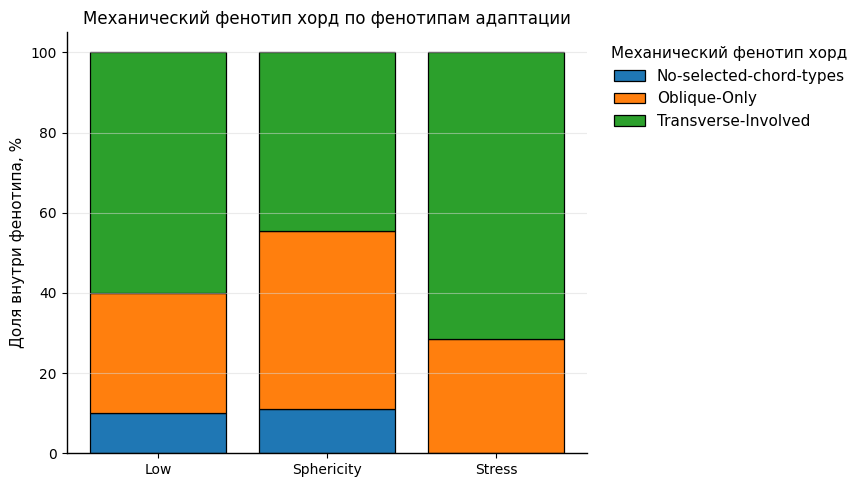

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\03_distribution_chord_type_complexity_class_by_adaptation_phenotype.png


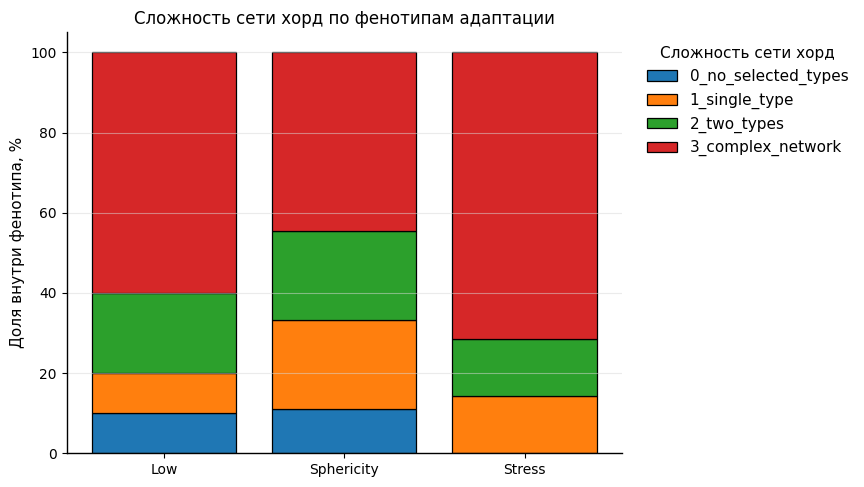

In [12]:
# ============================================================
# 11. Графики: классы хорд по фенотипам адаптации
# ============================================================

for col in categorical_chord_vars:
    order = [
        x for x in category_orders.get(col, sorted(main_df[col].dropna().unique()))
        if x in main_df[col].dropna().unique()
    ]

    ct_pct = pd.crosstab(
        main_df["adaptation_phenotype"],
        main_df[col],
        normalize="index",
        dropna=False,
    ).reindex(phenotype_order) * 100

    ct_pct = ct_pct[[c for c in order if c in ct_pct.columns]]

    fig, ax = plt.subplots(figsize=(8.8, 5.0))

    x = np.arange(len(ct_pct.index))
    bottom = np.zeros(len(ct_pct.index))

    for category in ct_pct.columns:
        values = ct_pct[category].fillna(0).values

        ax.bar(
            x,
            values,
            bottom=bottom,
            edgecolor="black",
            linewidth=0.9,
            label=str(category),
        )

        bottom += values

    ax.set_title(f"{pretty_names.get(col, col)} по фенотипам адаптации")
    ax.set_ylabel("Доля внутри фенотипа, %")
    ax.set_xticks(x)
    ax.set_xticklabels(phenotype_order)

    ax.legend(
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title=pretty_names.get(col, col),
    )

    apply_publication_style(ax)

    plt.tight_layout()

    save_fig(fig, f"03_distribution_{col}_by_adaptation_phenotype.png")
    plt.show()

In [13]:
# ============================================================
# 12. Статистика: классы хорд vs фенотипы адаптации
# ============================================================

def cramers_v_from_table(table):
    chi2, p, dof, expected = stats.chi2_contingency(table)

    n = table.to_numpy().sum()
    r, k = table.shape

    if n == 0 or min(r - 1, k - 1) == 0:
        return np.nan

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


cat_assoc_results = []

for col in categorical_chord_vars:
    order = [
        x for x in category_orders.get(col, sorted(main_df[col].dropna().unique()))
        if x in main_df[col].dropna().unique()
    ]

    ct = pd.crosstab(
        main_df["adaptation_phenotype"],
        main_df[col],
        dropna=False,
    ).reindex(phenotype_order)

    ct = ct[[c for c in order if c in ct.columns]]

    chi2, p_value, dof, expected = stats.chi2_contingency(ct)
    v = cramers_v_from_table(ct)

    cat_assoc_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "cramers_v": v,
        "min_expected_count": expected.min(),
        "interpretation_note": (
            "Осторожно: малые ожидаемые частоты"
            if expected.min() < 5
            else ""
        ),
    })

cat_assoc_df = pd.DataFrame(cat_assoc_results)

display(cat_assoc_df)

cat_assoc_df.to_excel(
    TABLES_DIR / "04_categorical_chord_classes_vs_adaptation_stats.xlsx",
    index=False,
)

,variable,pretty_name,chi2,p_value,dof,cramers_v,min_expected_count,interpretation_note
0,mechanical_chord_phenotype,Механический фенотип хорд,1.642998,0.801044,4,0.177753,0.538462,Осторожно: малые ожидаемые частоты
1,chord_type_complexity_class,Сложность сети хорд,1.857831,0.932298,6,0.189017,0.538462,Осторожно: малые ожидаемые частоты


mechanical_chord_phenotype,No-selected-chord-types,Oblique-Only,Transverse-Involved
adaptation_phenotype,,,
Low,0.26,-0.25,0.10
Sphericity,0.37,0.50,-0.52
Stress,-0.73,-0.27,0.48


Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\04_standardized_residuals_mechanical_chord_phenotype.png


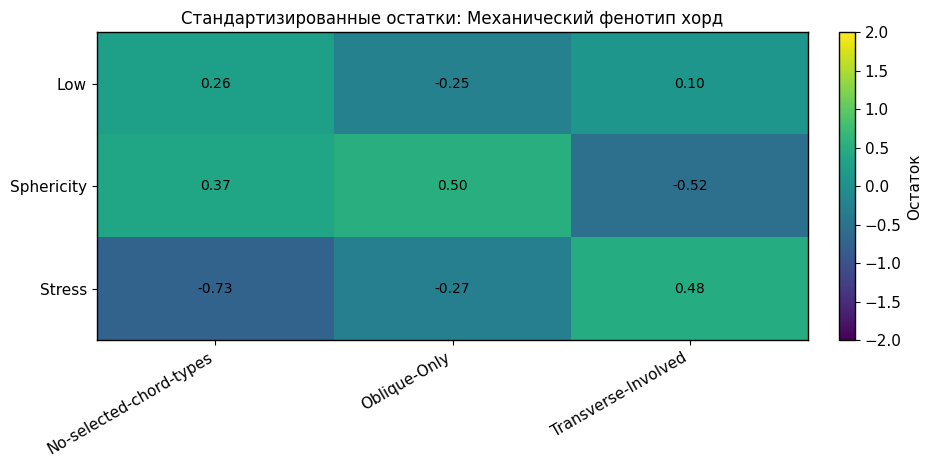

chord_type_complexity_class,0_no_selected_types,1_single_type,2_two_types,3_complex_network
adaptation_phenotype,,,,
Low,0.26,-0.43,0.06,0.10
Sphericity,0.37,0.52,0.20,-0.52
Stress,-0.73,-0.07,-0.30,0.48


Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\04_standardized_residuals_chord_type_complexity_class.png


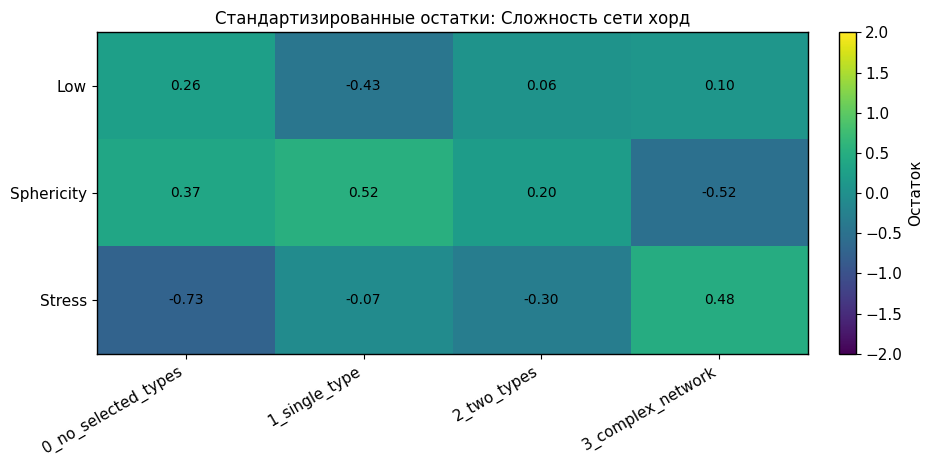

In [14]:
# ============================================================
# 13. Heatmap стандартизированных остатков
# ============================================================

for col in categorical_chord_vars:
    order = [
        x for x in category_orders.get(col, sorted(main_df[col].dropna().unique()))
        if x in main_df[col].dropna().unique()
    ]

    ct = pd.crosstab(
        main_df["adaptation_phenotype"],
        main_df[col],
        dropna=False,
    ).reindex(phenotype_order)

    ct = ct[[c for c in order if c in ct.columns]]

    chi2, p_value, dof, expected = stats.chi2_contingency(ct)

    expected_df = pd.DataFrame(
        expected,
        index=ct.index,
        columns=ct.columns,
    )

    residuals = (ct - expected_df) / np.sqrt(expected_df)

    display(residuals.round(2))

    fig, ax = plt.subplots(figsize=(9.5, 4.8))

    im = ax.imshow(
        residuals.values,
        aspect="auto",
        vmin=-2,
        vmax=2,
    )

    ax.set_xticks(range(residuals.shape[1]))
    ax.set_yticks(range(residuals.shape[0]))

    ax.set_xticklabels(residuals.columns, rotation=30, ha="right")
    ax.set_yticklabels(residuals.index)

    for i in range(residuals.shape[0]):
        for j in range(residuals.shape[1]):
            ax.text(
                j,
                i,
                f"{residuals.values[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black",
            )

    ax.set_title(f"Стандартизированные остатки: {pretty_names.get(col, col)}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Остаток")

    plt.tight_layout()

    save_fig(fig, f"04_standardized_residuals_{col}.png")
    plt.show()

In [15]:
# ============================================================
# 14. Количественные признаки архитектуры хорд по фенотипам
# ============================================================

numeric_chord_vars = [
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
]

numeric_chord_vars = [
    col for col in numeric_chord_vars
    if col in main_df.columns and main_df[col].notna().sum() > 0
]

print("Количественные признаки архитектуры хорд:")
for col in numeric_chord_vars:
    print("-", col, "n =", main_df[col].notna().sum())

numeric_chord_summary = (
    main_df
    .groupby("adaptation_phenotype")[numeric_chord_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reindex(phenotype_order)
)

display(numeric_chord_summary)

numeric_chord_summary.to_excel(
    TABLES_DIR / "05_numeric_chord_architecture_by_adaptation_summary.xlsx"
)

Количественные признаки архитектуры хорд:
- lv_false_tendon_total_count n = 23
- transverse_load n = 24
- oblique_load n = 24
- long_oblique_bridge_load n = 24
- chord_type_diversity n = 26


lv_false_tendon_total_count                                      transverse_load                                      oblique_load                      \
                                           count      mean       std median  min  max           count      mean       std median  min  max        count      mean       std   
adaptation_phenotype                                                                                                                                                          
Low                                            9  2.666667  1.414214    2.0  1.0  5.0               9  2.555556  2.403701    2.0  0.0  6.0            9  1.888889  0.927961   
Sphericity                                     8  2.125000  1.246423    2.0  0.0  4.0               8  1.500000  1.772811    1.0  0.0  4.0            8  1.500000  0.925820   
Stress                                         6  2.333333  1.211060    2.5  1.0  4.0               7  2.000000  1.632993    2.0  0.0  4.0            7  1.571429  1.272418   

                                      long_oblique_bridge_load                                      chord_type_diversity                                     
                     median  min  max                    count      mean       std median  min  max                count      mean       std median min max  
adaptation_phenotype                                                                                                                                         
Low                     2.0  1.0  4.0                        9  1.333333  0.707107    1.0  0.0  2.0                   10  2.900000  1.595131    3.5   0   5  
Sphericity              1.5  0.0  3.0                        8  0.625000  0.744024    0.5  0.0  2.0                    9  2.222222  1.394433    2.0   0   4  
Stress                  1.0  0.0  4.0                        7  0.714286  0.755929    1.0  0.0  2.0                    7  2.857143  1.069045    3.0   1   4

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\16_adaptation_phenotypes_vs_chord_architecture\figures\05_numeric_chord_architecture_by_adaptation.png


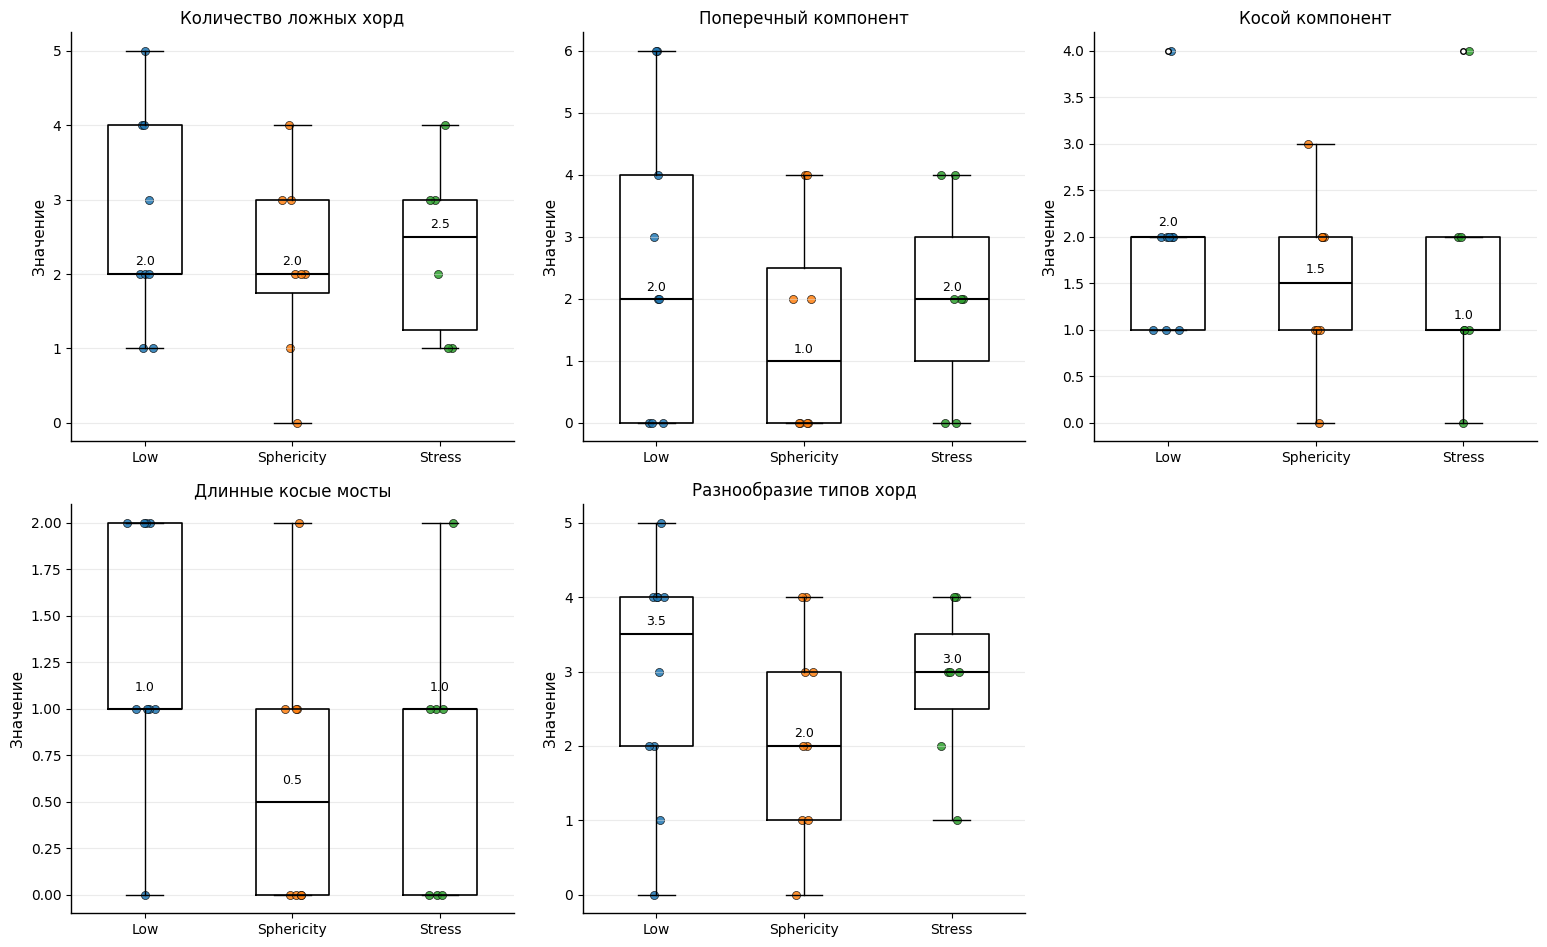

In [16]:
# ============================================================
# 15. Графики: количественная архитектура хорд по фенотипам
# ============================================================

n_vars = len(numeric_chord_vars)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.2 * n_cols, 4.8 * n_rows),
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, numeric_chord_vars):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype"] == phenotype,
            col,
        ].dropna()
        for phenotype in phenotype_order
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.04, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=34,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.85,
        )

    medians = [np.median(values) for values in data_by_group]
    for i, med in enumerate(medians, start=1):
        ax.text(
            i,
            med + 0.08,
            f"{med:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(phenotype_order)

    apply_publication_style(ax)

for ax in axes[len(numeric_chord_vars):]:
    ax.axis("off")

plt.tight_layout()

save_fig(fig, "05_numeric_chord_architecture_by_adaptation.png")
plt.show()

In [17]:
# ============================================================
# 16. Kruskal-Wallis: количественная архитектура хорд vs фенотипы
# ============================================================

numeric_assoc_results = []

for col in numeric_chord_vars:
    groups = [
        main_df.loc[
            main_df["adaptation_phenotype"] == phenotype,
            col,
        ].dropna()
        for phenotype in phenotype_order
    ]

    h_stat, p_value = stats.kruskal(*groups)

    numeric_assoc_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "H": h_stat,
        "p_value": p_value,
        "n_low": len(groups[0]),
        "n_sphericity": len(groups[1]),
        "n_stress": len(groups[2]),
        "median_low": np.median(groups[0]),
        "median_sphericity": np.median(groups[1]),
        "median_stress": np.median(groups[2]),
    })

numeric_assoc_df = pd.DataFrame(numeric_assoc_results)

display(numeric_assoc_df)

numeric_assoc_df.to_excel(
    TABLES_DIR / "06_numeric_chord_architecture_vs_adaptation_stats.xlsx",
    index=False,
)

,variable,pretty_name,H,p_value,n_low,n_sphericity,n_stress,median_low,median_sphericity,median_stress
0,lv_false_tendon_total_count,Количество ложных хорд,0.470680,0.790302,9,8,6,2.0,2.0,2.5
1,transverse_load,Поперечный компонент,0.922680,0.630438,9,8,7,2.0,1.0,2.0
2,oblique_load,Косой компонент,0.872527,0.646447,9,8,7,2.0,1.5,1.0
3,long_oblique_bridge_load,Длинные косые мосты,4.206381,0.122066,9,8,7,1.0,0.5,1.0
4,chord_type_diversity,Разнообразие типов хорд,1.393629,0.498170,10,9,7,3.5,2.0,3.0


In [18]:
# ============================================================
# 17. Stress vs Other: количественная архитектура хорд
# ============================================================

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    if len(x) == 0 or len(y) == 0:
        return np.nan

    greater = 0
    less = 0

    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)

    return (greater - less) / (len(x) * len(y))


stress_vs_other_chord_results = []

plot_df = main_df.copy()
plot_df["stress_group"] = np.where(
    plot_df["adaptation_phenotype"] == "Stress",
    "Stress",
    "Other",
)

for col in numeric_chord_vars:
    stress_values = plot_df.loc[
        plot_df["stress_group"] == "Stress",
        col,
    ].dropna()

    other_values = plot_df.loc[
        plot_df["stress_group"] == "Other",
        col,
    ].dropna()

    u_stat, p_value = stats.mannwhitneyu(
        stress_values,
        other_values,
        alternative="two-sided",
    )

    delta = cliffs_delta(stress_values, other_values)

    stress_vs_other_chord_results.append({
        "variable": col,
        "pretty_name": pretty_names.get(col, col),
        "n_stress": len(stress_values),
        "n_other": len(other_values),
        "median_stress": np.median(stress_values),
        "median_other": np.median(other_values),
        "mean_stress": np.mean(stress_values),
        "mean_other": np.mean(other_values),
        "mannwhitney_u": u_stat,
        "p_value": p_value,
        "cliffs_delta_stress_vs_other": delta,
    })

stress_vs_other_chord_df = pd.DataFrame(stress_vs_other_chord_results)

display(stress_vs_other_chord_df)

stress_vs_other_chord_df.to_excel(
    TABLES_DIR / "07_stress_vs_other_chord_architecture.xlsx",
    index=False,
)

,variable,pretty_name,n_stress,n_other,median_stress,median_other,mean_stress,mean_other,mannwhitney_u,p_value,cliffs_delta_stress_vs_other
0,lv_false_tendon_total_count,Количество ложных хорд,6,17,2.5,2.0,2.333333,2.411765,49.5,0.942663,-0.029412
1,transverse_load,Поперечный компонент,7,17,2.0,2.0,2.000000,2.058824,61.0,0.947044,0.025210
2,oblique_load,Косой компонент,7,17,1.0,2.0,1.571429,1.705882,51.0,0.587062,-0.142857
3,long_oblique_bridge_load,Длинные косые мосты,7,17,1.0,1.0,0.714286,1.000000,47.5,0.435318,-0.201681
4,chord_type_diversity,Разнообразие типов хорд,7,19,3.0,3.0,2.857143,2.578947,72.0,0.766661,0.082707


## Интерпретация связи фенотипов адаптации с архитектурой хорд

Грубые категориальные классификации хорд (`mechanical_chord_phenotype` и `chord_type_complexity_class`) не показали выраженной связи с механико-гемодинамическими фенотипами адаптации ЛЖ. Значения Cramer's V были низкими, а стандартизированные остатки не выявили отдельных ячеек с сильным отклонением от ожидаемых частот.

Визуально можно отметить лишь слабые тенденции: стресс-доминантный фенотип несколько чаще связан с `Transverse-Involved` и `complex_network`, тогда как геометрически-сферичный фенотип несколько чаще связан с `Oblique-Only` и менее сложными вариантами сети. Однако эти различия не являются устойчивыми и должны рассматриваться только как исследовательские наблюдения.

Количественные признаки архитектуры хорд также не показали яркого разделения фенотипов. Простое количество хорд, поперечный компонент, косой компонент, длинные косые мосты и разнообразие типов хорд не формируют очевидного паттерна, который бы объяснял принадлежность к Stress-фенотипу.

Таким образом, на данном этапе наиболее устойчивый результат связан не с архитектурой хорд напрямую, а с тем, что стресс-доминантный фенотип адаптации имеет более высокую систолическую механическую неоднородность по DICOR CV ССОУ.